In [1]:
# csvファイルの読み込み
import pandas as pd
data = pd.read_csv('../data/clean/clean_NVDA_data.csv')

In [2]:
data.head()

,Date,Close,High,Low,Open,Volume
0,2020-01-03,5.876162,5.919971,5.827125,5.852017,205384000
1,2020-01-06,5.900805,5.906032,5.756683,5.782819,262636000
2,2020-01-07,5.972245,6.018046,5.884129,5.929183,314856000
3,2020-01-08,5.983447,6.024767,5.927939,5.968014,277108000
4,2020-01-09,6.049160,6.121594,5.995394,6.069820,255112000


In [3]:
data.dtypes

Date       object
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object

In [4]:
data = pd.read_csv('../data/target_label_data/label_NVDA_data.csv')

In [5]:
# 日付変換前のコピーを取っておく
raw_date = data['Date'].copy()

# 日付変換後（NaTになるものを含む）
data['Date'] = pd.to_datetime(data['Date'], errors='coerce')

# 変換に失敗した（=NaTになった）行を抽出
invalid_dates = raw_date[data['Date'].isna()]

print("変換に失敗した日付データ:")
print(invalid_dates)


変換に失敗した日付データ:
Series([], Name: Date, dtype: object)


In [6]:
data.dtypes

Date         datetime64[ns]
Close               float64
High                float64
Low                 float64
Open                float64
Volume                int64
Peaklabel             int64
dtype: object

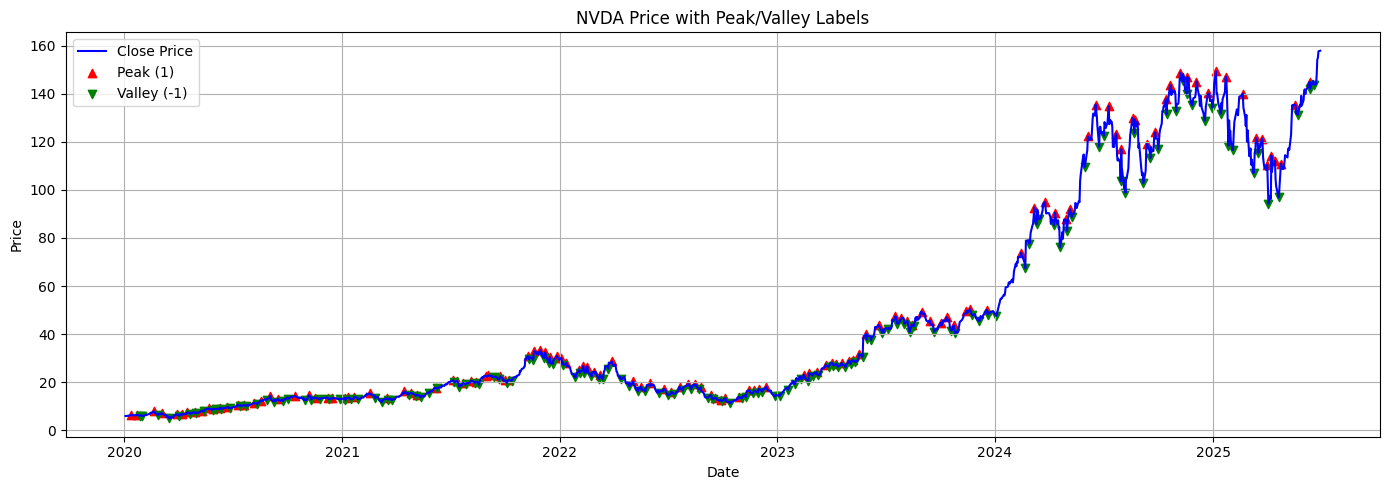

In [7]:
import matplotlib.pyplot as plt

# 日付型に変換
data['Date'] = pd.to_datetime(data['Date'], errors='coerce')

# 可視化：Close価格 + PeakLabel（山=赤点、谷=緑点）
plt.figure(figsize=(14, 5))
plt.plot(data['Date'], data['Close'], label='Close Price', color='blue')

# 山（Peak=1）の位置に赤丸
peak_dates = data[data['Peaklabel'] == 1]
plt.scatter(peak_dates['Date'], peak_dates['Close'], color='red', label='Peak (1)', marker='^')

# 谷（Peak=-1）の位置に緑丸
valley_dates = data[data['Peaklabel'] == -1]
plt.scatter(valley_dates['Date'], valley_dates['Close'], color='green', label='Valley (-1)', marker='v')

plt.title(f"NVDA Price with Peak/Valley Labels")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [8]:
data.dtypes

Date         datetime64[ns]
Close               float64
High                float64
Low                 float64
Open                float64
Volume                int64
Peaklabel             int64
dtype: object

## ① 移動平均（MA）と終値グラフ

### ✅ 見方のポイント：
- **Close（黒線）**：実際の株価の終値
- **MA 5（青線）**：直近5期間（例：5日、5時間）の平均値
- **MA 10（オレンジ線）**：直近10期間の平均値

### 💡 解釈：
- **黒線が上に抜けたらトレンド上昇（ゴールデンクロス）** → 買いシグナル
- **黒線が下に抜けたらトレンド下降（デッドクロス）** → 売りシグナル
- 5MAと10MAの**乖離幅が大きいほど強いトレンド**

---

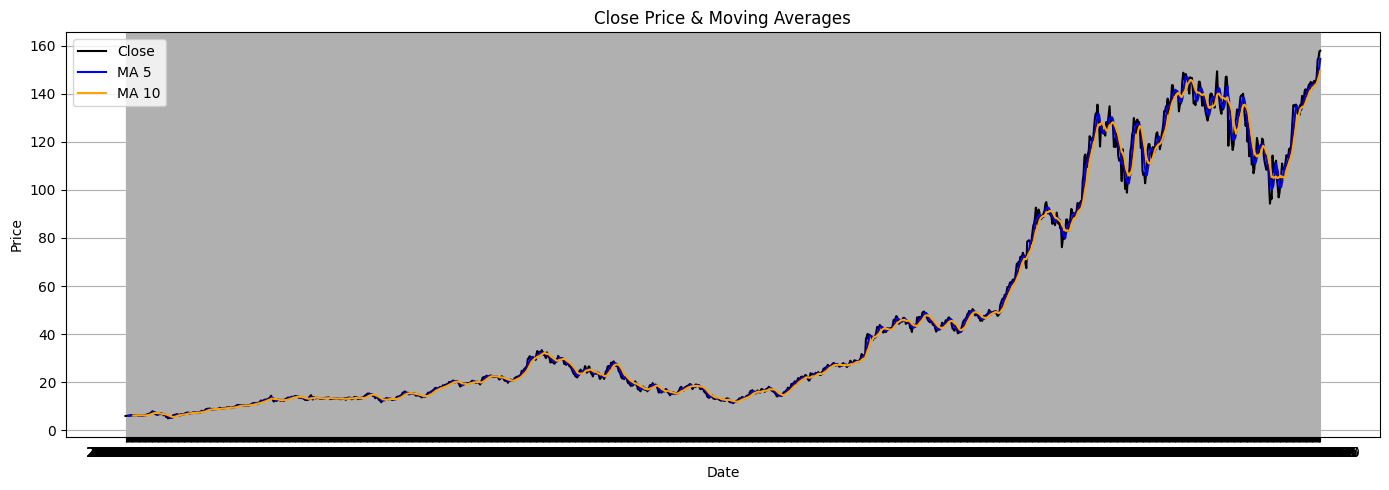

In [9]:
data = pd.read_csv('../data/features/features_NVDA_data.csv')

plt.figure(figsize=(14, 5))
plt.plot(data['Date'], data['Close'], label='Close', color='black')
plt.plot(data['Date'], data['ma_5'], label='MA 5', color='blue')
plt.plot(data['Date'], data['ma_10'], label='MA 10', color='orange')
plt.title("Close Price & Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## ② RSI（Relative Strength Index）

### ✅ 見方のポイント：
- RSIは **0～100の範囲**
- 一般的な基準：
  - 70以上：**買われすぎ** → 株価が下がるかも（売りシグナル）
  - 30以下：**売られすぎ** → 株価が上がるかも（買いシグナル）

### 💡 解釈：
- RSIが70を超えた後に下がり始めると**売り圧力**
- RSIが30を下回ってから上昇すると**買いの兆し**
- トレンド転換の可能性を**事前に察知する**のに使える

---

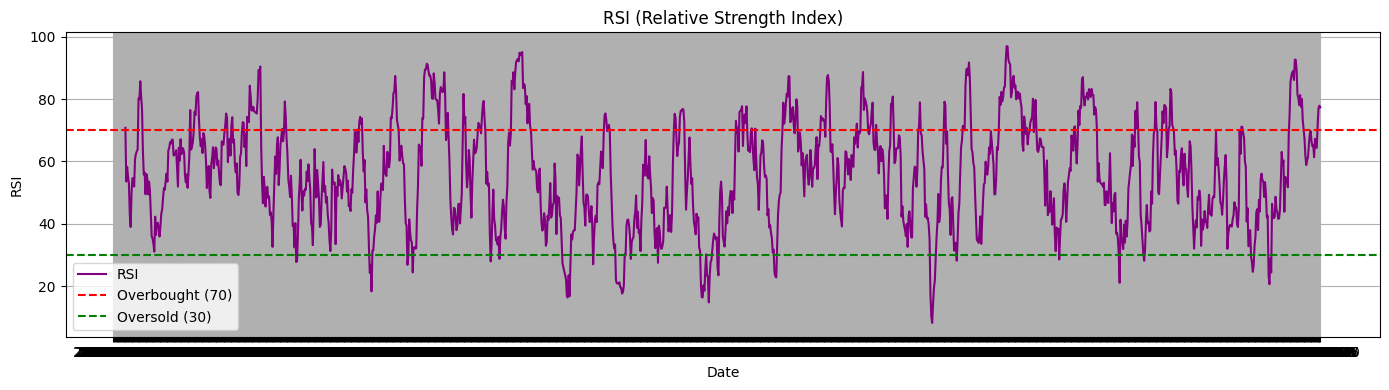

In [10]:
plt.figure(figsize=(14, 4))
plt.plot(data['Date'], data['rsi'], label='RSI', color='purple')
plt.axhline(70, color='red', linestyle='--', label='Overbought (70)')
plt.axhline(30, color='green', linestyle='--', label='Oversold (30)')
plt.title("RSI (Relative Strength Index)")
plt.xlabel("Date")
plt.ylabel("RSI")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## ③ MACD（移動平均収束拡散法）

### ✅ 見方のポイント：
- **MACD（青）**：短期EMA - 長期EMA（トレンドの強さ）
- **シグナル（赤）**：MACDの移動平均（9期間）

### 💡 解釈：
- **MACDがシグナルを上に抜ける** → 上昇トレンド（買い）
- **MACDがシグナルを下に抜ける** → 下降トレンド（売り）
- 上下の交差点が「トレンド転換のサイン」になる

---

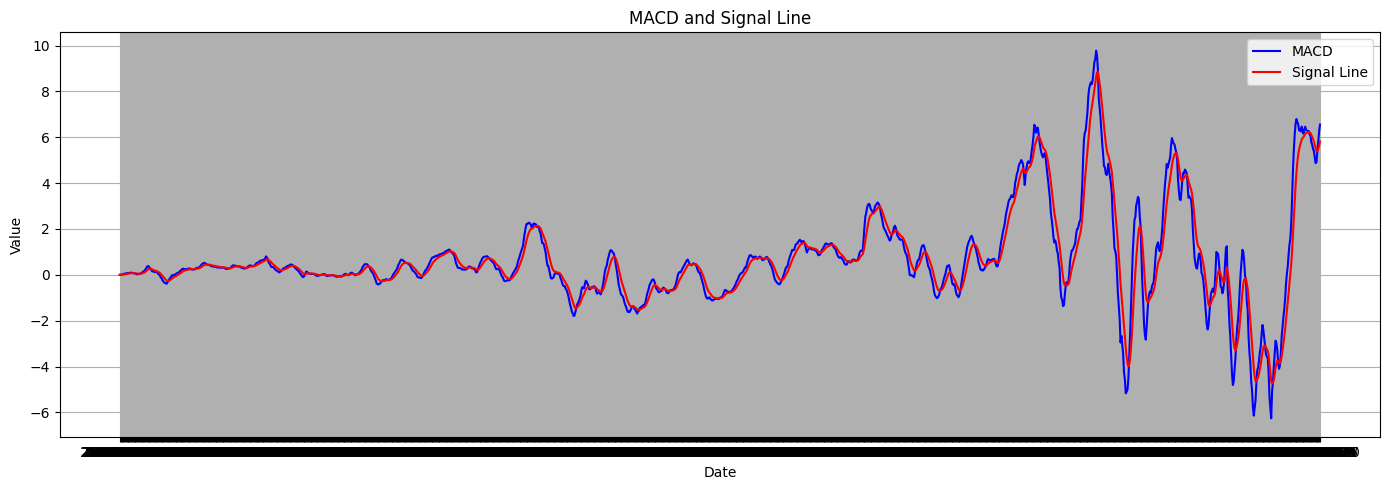

In [11]:
plt.figure(figsize=(14, 5))
plt.plot(data['Date'], data['macd'], label='MACD', color='blue')
plt.plot(data['Date'], data['macd_signal'], label='Signal Line', color='red')
plt.title("MACD and Signal Line")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## ④ ボリンジャーバンド（Bollinger Band）

### ✅ 見方のポイント：
- 中央線：20期間の移動平均
- 上下のバンド：±2σ（標準偏差）の範囲
- 株価の約95%がこの中に収まる

### 💡 解釈：
- **上限に近い → 買われすぎ（反落の可能性）**
- **下限に近い → 売られすぎ（反発の可能性）**
- バンドが狭くなってから広がる時 → **ボラティリティ上昇（トレンド開始）**

---

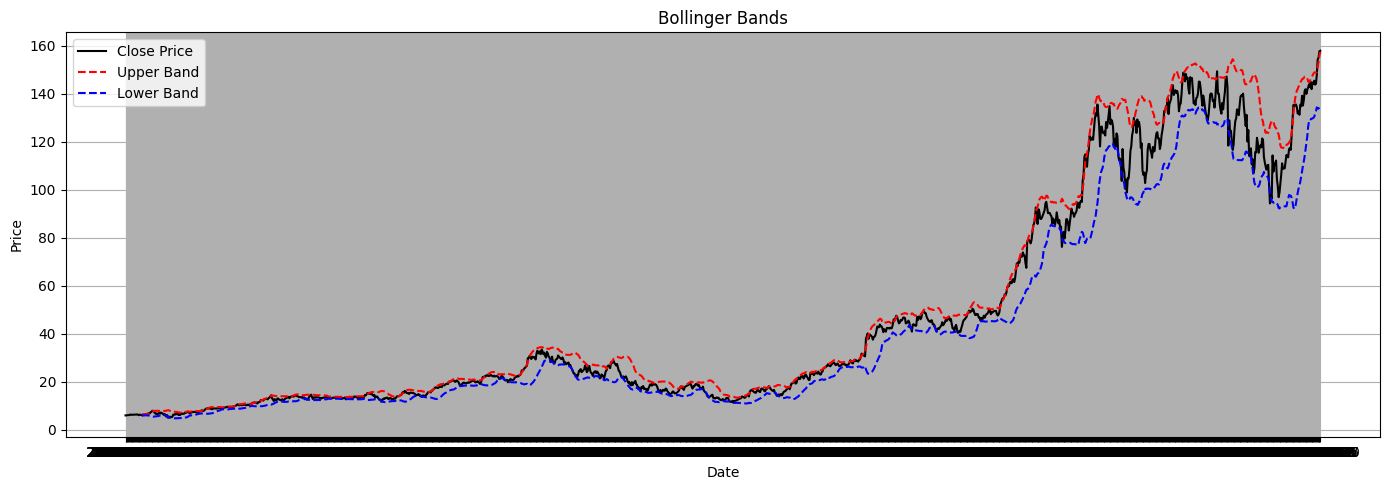

In [12]:
plt.figure(figsize=(14, 5))
plt.plot(data['Date'], data['Close'], label='Close Price', color='black')
plt.plot(data['Date'], data['bb_upper'], label='Upper Band', color='red', linestyle='--')
plt.plot(data['Date'], data['bb_lower'], label='Lower Band', color='blue', linestyle='--')
plt.fill_between(data['Date'], data['bb_lower'], data['bb_upper'], color='gray', alpha=0.1)
plt.title("Bollinger Bands")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## ⑤ 出来高（Volume）と移動平均

### ✅ 見方のポイント：
- 灰色線：日々の出来高（取引量）
- 緑色線：直近5期間の平均出来高

### 💡 解釈：
- 出来高が平均より急増している → **注目度アップ、転換点の可能性**
- 出来高が増えながら価格が上昇 → **強い買い**
- 出来高が減っている → **様子見、方向感なし**

---

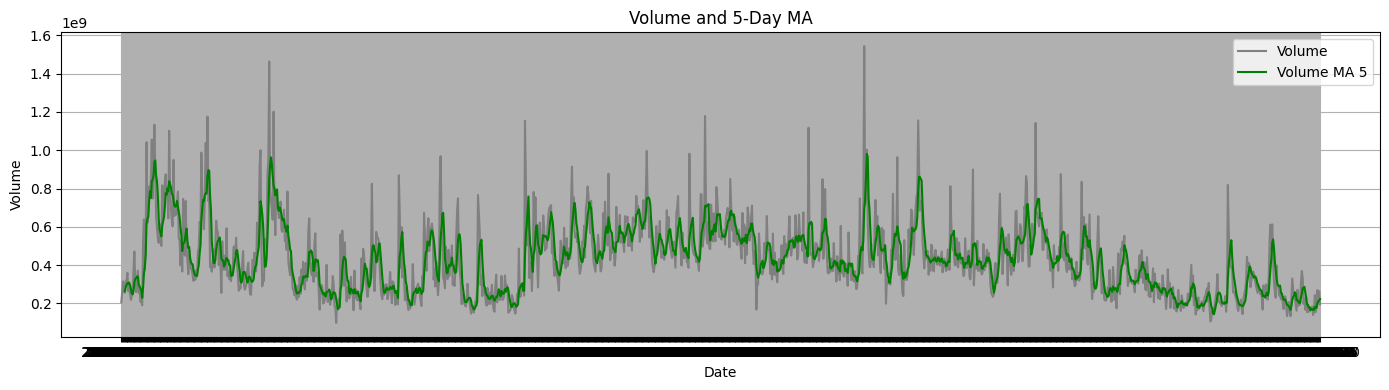

In [13]:
plt.figure(figsize=(14, 4))
plt.plot(data['Date'], data['Volume'], label='Volume', color='gray')
plt.plot(data['Date'], data['vol_ma_5'], label='Volume MA 5', color='green')
plt.title("Volume and 5-Day MA")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 🧠 総合的な見方

1. **RSIが高く、価格がBB上限を超えている** → **天井の可能性**
2. **MACDがシグナルを下抜け、出来高も上昇** → **本格的な売りトレンド開始**
3. **RSIが低く、価格がBB下限に接近＋MACDが上抜ける** → **反発の兆し**
4. **価格がMAより下でMACDも下** → **下降トレンド継続中**

---

In [14]:
data.head()

,Date,Close,High,Low,Open,Volume,Peaklabel,dayofweek,is_month_end,ma_5,...,return_5,diff,rsi,macd,macd_signal,bb_upper,bb_lower,bb_width,vol_ma_5,vol_change
0,2020-01-03,5.876162,5.919971,5.827125,5.852017,205384000,0,4,0,NaN,...,NaN,0.024145,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN
1,2020-01-06,5.900805,5.906032,5.756683,5.782819,262636000,0,0,0,NaN,...,NaN,0.117986,NaN,0.001966,0.000393,NaN,NaN,NaN,NaN,0.278756
2,2020-01-07,5.972245,6.018046,5.884129,5.929183,314856000,0,1,0,NaN,...,NaN,0.043063,NaN,0.009183,0.002151,NaN,NaN,NaN,NaN,0.198830
3,2020-01-08,5.983447,6.024767,5.927939,5.968014,277108000,0,2,0,NaN,...,NaN,0.015433,NaN,0.015626,0.004846,NaN,NaN,NaN,NaN,-0.119890
4,2020-01-09,6.049160,6.121594,5.995394,6.069820,255112000,0,3,0,5.956364,...,NaN,-0.020660,NaN,0.025738,0.009024,NaN,NaN,NaN,263019200.0,-0.079377


In [15]:
# 欠損値（NaN）を1つでも含む行を削除
data = data.dropna()

# インデックスを振り直す（オプション）
data = data.reset_index(drop=True)


In [16]:
print(data.columns.tolist())


['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Peaklabel', 'dayofweek', 'is_month_end', 'ma_5', 'ma_10', 'ma_ratio', 'return_1', 'return_5', 'diff', 'rsi', 'macd', 'macd_signal', 'bb_upper', 'bb_lower', 'bb_width', 'vol_ma_5', 'vol_change']


In [17]:
from sklearn.preprocessing import MinMaxScaler

# 正規処理
def normalize(data):
    features = [
    'Close', 'High', 'Low', 'Open', 'Volume', 
    'dayofweek', 'is_month_end', 'ma_5', 'return_5', 'diff', 'rsi',
    'macd', 'macd_signal', 'bb_upper', 'bb_lower', 'bb_width',
    'vol_ma_5', 'vol_change'
    ]

    # スケーラのインスタンス化
    close_scaler = MinMaxScaler(feature_range=(0, 1))
    features_scaler = MinMaxScaler(feature_range=(0, 1))

    # スケーリングの適用
    #data['Peaklabel'] = close_scaler.fit_transform(data[['Peaklabel']]) 

    # 特徴量のスケーリング
    data[features] = features_scaler.fit_transform(data[features])

    return data, close_scaler, features_scaler

# 正規化の実行
data, close_scaler, features_scaler = normalize(data)
# 正規化後のデータの確認
data.head()

,Date,Close,High,Low,Open,Volume,Peaklabel,dayofweek,is_month_end,ma_5,...,return_5,diff,rsi,macd,macd_signal,bb_upper,bb_lower,bb_width,vol_ma_5,vol_change
0,2020-01-31,0.006489,0.005576,0.008868,0.007098,0.188472,-1,1.00,1.0,0.006001,...,0.316380,0.484041,0.392266,0.392464,0.353329,0.000111,0.009118,0.001657,0.235288,0.211448
1,2020-02-03,0.007123,0.005035,0.008983,0.005757,0.109044,0,0.00,0.0,0.006005,...,0.424402,0.494043,0.346570,0.391754,0.352745,0.000044,0.009277,0.001004,0.183987,0.080860
2,2020-02-04,0.008229,0.006136,0.010392,0.007433,0.120095,0,0.25,0.0,0.005977,...,0.416909,0.491142,0.469282,0.392024,0.352342,0.000000,0.009522,0.000189,0.174577,0.164011
3,2020-02-05,0.008819,0.006866,0.010949,0.008400,0.076303,0,0.50,0.0,0.006151,...,0.463920,0.489227,0.522257,0.392667,0.352171,0.000060,0.009660,0.000000,0.162495,0.098015
4,2020-02-06,0.009386,0.007166,0.011191,0.008424,0.083263,0,0.75,0.0,0.006432,...,0.488861,0.491972,0.523425,0.393576,0.352248,0.000209,0.009752,0.000225,0.145260,0.160843


In [18]:
features_cols = ['Close', 'High', 'Low', 'Open', 'Volume', 
    'dayofweek', 'is_month_end', 'ma_5', 'return_5', 'diff', 'rsi',
    'macd', 'macd_signal', 'bb_upper', 'bb_lower', 'bb_width',
    'vol_ma_5', 'vol_change']

target_cols = ['Peaklabel']

In [19]:
import numpy as np

def create_sequences(data, seq_length, target_col='Peaklabel'):
    X, y = [], []  # 入力データ（特徴量系列）と正解ラベルのリストを初期化
    
    # データをseq_length（例:10）ずつスライドさせながら
    # 連続した特徴量の部分系列を抽出し、教師ラベルを取得するループ
    for i in range(len(data) - seq_length):
        # i番目からi+seq_length番目までの特徴量部分系列を取得（2次元配列）
        # features_cols は使用する特徴量列名のリスト（事前に定義されている想定）
        X.append(data.iloc[i:i+seq_length][features_cols].values)
        
        # i+seq_length番目のターゲット列の値（教師ラベル）を取得
        y.append(data.iloc[i + seq_length][target_col])
    
    # リストをNumPy配列に変換して返す
    # Xの形状は (サンプル数, seq_length, 特徴量数)
    # yの形状は (サンプル数,)
    return np.array(X), np.array(y)

# シーケンス長（時系列の長さ）を10に設定
SEQ_LENGTH = 10

# 関数を使ってノイズなしの時系列シーケンスXとラベルyを作成
X, y = create_sequences(data, SEQ_LENGTH)

# 結果の配列の形状を表示
print('X shape:', X.shape, 'y shape:', y.shape)

X shape: (1350, 10, 18) y shape: (1350,)


In [20]:
from tensorflow.keras.utils import to_categorical

def train_test_split_one_hot(X, y, test_size=0.2):
    """
    LSTMなどの分類モデル用に時系列データを分割し、yをone-hotエンコードする関数。
    - yは [-1, 0, 1] の3クラスラベルと想定し、0,1,2に変換してからone-hot化。
    """
    split_idx = int(len(X) * (1 - test_size))
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]

    y_train = to_categorical(y_train + 1, num_classes=3)
    y_test = to_categorical(y_test + 1, num_classes=3)

    return X_train, X_test, y_train, y_test

def train_test_split_raw_label(X, y, test_size=0.2):
    """
    XGBoostなど回帰やラベルのまま使うモデル用に時系列データを分割する関数。
    yは変換せずそのまま返す。
    """
    split_idx = int(len(X) * (1 - test_size))
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]

    return X_train, X_test, y_train, y_test


# 呼び出し例
TEST_SIZE = 0.2

# LSTM用（one-hotラベル）
X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split_one_hot(X, y, test_size=TEST_SIZE)

# XGBoost用（ラベルそのまま）
X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split_raw_label(X, y, test_size=TEST_SIZE)

# XGBoostは入力を2次元に変換
xgb_X_train = X_train_xgb.reshape(X_train_xgb.shape[0], -1)
xgb_X_test = X_test_xgb.reshape(X_test_xgb.shape[0], -1)

# ここからXGBoostモデルの学習やLSTMモデルの学習に進めます


# モデル構築

In [21]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam


def build_lstm_model(input_shape, lstm_units=64, dense_units=32, dropout_rate=0.2, learning_rate=0.001):
    """3クラス分類用LSTMモデルを構築"""
    model = Sequential([
        # LSTM層（時系列特徴抽出）
        LSTM(lstm_units, return_sequences=True, input_shape=input_shape),
        BatchNormalization(),
        Dropout(dropout_rate),

        # 2つ目のLSTM（時系列の要約）
        LSTM(lstm_units // 2),
        BatchNormalization(),
        Dropout(dropout_rate),

        # 全結合層
        Dense(dense_units, activation='relu'),

        # 出力層：3クラス分類 → softmax
        Dense(3, activation='softmax')
    ])

    # クロスエントロピー＋精度
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

    return model


SEQ_LENGTH = 7  # 時系列の長さ（例：30日分のデータを使用）

# モデルの構築
lstm_model = build_lstm_model((SEQ_LENGTH, X_train_lstm.shape[2])) # 時系列の長さ，特徴量の数
lstm_model.summary() # モデルの概要

/opt/homebrew/var/pyenv/versions/3.12.6/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 7, 64)          │        21,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 7, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,203 (137.51 KB)

 Trainable params: 35,011 (136.76 KB)

 Non-trainable params: 192 (768.00 B)

In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_lstm_classification(y_true, y_pred):
    """LSTMモデル（分類）の評価関数"""

    # One-hot → ラベル（[0, 1, 0] → 1）
    y_true_labels = y_true.argmax(axis=1) if len(y_true.shape) > 1 else y_true
    y_pred_labels = y_pred.argmax(axis=1) if len(y_pred.shape) > 1 else y_pred

    accuracy = accuracy_score(y_true_labels, y_pred_labels)
    precision = precision_score(y_true_labels, y_pred_labels, average='macro', zero_division=0)
    recall = recall_score(y_true_labels, y_pred_labels, average='macro', zero_division=0)
    f1 = f1_score(y_true_labels, y_pred_labels, average='macro', zero_division=0)

    print("LSTMモデルの評価結果")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

# LSTMモデルの予測（softmax出力）
lstm_pred = lstm_model.predict(X_test_lstm)

# 評価実行
evaluate_lstm_classification(y_test_lstm, lstm_pred)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
LSTMモデルの評価結果
Accuracy : 0.0963
Precision: 0.0321
Recall   : 0.3333
F1 Score : 0.0586


In [23]:
import xgboost as xgb


# XGBoostモデルの構築
def build_xgboost_model(n_estimators=100,max_depth=5,learning_rate=0.1):
    """XGBoostモデルを構築する関数"""
    model = xgb.XGBRegressor(
        # 回帰タスクに適した損失関数（MSE）
        objextive='reg:squarederror',
        # 決定木の数
        n_estimators=n_estimators,
        # 決定機の深さ
        max_depth=max_depth,
        # 学習率(小さいほど安定，収束が遅くなる)
        learning_rate=learning_rate,
        # 乱数シード
        random_state=42
    )
    return model

# XGBoostモデルの構築
xgb_X_train = X_train_xgb.reshape(X_train_xgb.shape[0],-1) # 2次元に変換
xgb_X_test = X_test_xgb.reshape(X_test_xgb.shape[0],-1) # 2次元に変換

# モデルの構築
xgb_model = build_xgboost_model()

In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

def convert_regression_to_class(y_pred):
    """
    XGBoost回帰の連続値予測を3クラスラベルに丸める関数。
    -1.0未満 → -1
    -1.0〜0.0未満 → 0
    0.0以上 → 1
    （境界は必要に応じて調整してください）
    """
    y_class = np.where(y_pred < -0.5, -1,
               np.where(y_pred < 0.5, 0, 1))
    return y_class

def evaluate_xgboost_classification(y_true, y_pred):
    """XGBoost回帰の予測を分類ラベルに変換して評価"""
    y_true_labels = y_true.astype(int)  # 明示的に整数型へ変換
    y_pred_labels = convert_regression_to_class(y_pred)

    accuracy = accuracy_score(y_true_labels, y_pred_labels)
    precision = precision_score(y_true_labels, y_pred_labels, average='macro', zero_division=0)
    recall = recall_score(y_true_labels, y_pred_labels, average='macro', zero_division=0)
    f1 = f1_score(y_true_labels, y_pred_labels, average='macro', zero_division=0)

    print("XGBoostモデルの評価結果")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")



# XGBoostモデルの学習
xgb_model.fit(xgb_X_train, y_train_xgb)

# 予測
xgb_pred = xgb_model.predict(xgb_X_test)

# 評価実行
evaluate_xgboost_classification(y_test_xgb, xgb_pred)


/opt/homebrew/var/pyenv/versions/3.12.6/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [04:35:57] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "objextive" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoostモデルの評価結果
Accuracy : 0.7667
Precision: 0.3156
Recall   : 0.3391
F1 Score : 0.3223


# 訓練モデル

In [25]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# 早期停止
early_stopping = EarlyStopping(
    monitor='val_loss',  # 検証データの損失値を監視
    patience=10,  # 10エポック改善が見られない場合に停止
    restore_best_weights=True  # 最適な重みを復元
)

# モデルの保存
checkpoint = ModelCheckpoint(
    'model/best_model.keras',  # ベストなモデルの重みを保存
    save_best_only=True,  # 検証データの損失が改善した場合のみに保存
)

# LSTMモデルの学習
history = lstm_model.fit(
    X_train_lstm, y_train_lstm,  # トレーニングデータ
    epochs=100,  # エポック数
    batch_size=32,  # バッチサイズ
    validation_split=0.2,  # 検証データの割合
    callbacks=[early_stopping, checkpoint],  # コールバック
    verbose=1  # ログの表示
)


Epoch 1/100


27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.3646 - loss: 1.3816 - val_accuracy: 0.8380 - val_loss: 1.0248
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7632 - loss: 0.7661 - val_accuracy: 0.8380 - val_loss: 0.9467
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7859 - loss: 0.6869 - val_accuracy: 0.8380 - val_loss: 0.9151
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7795 - loss: 0.7220 - val_accuracy: 0.8380 - val_loss: 0.8762
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7751 - loss: 0.7061 - val_accuracy: 0.8380 - val_loss: 0.8307
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8064 - loss: 0.6494 - val_accuracy: 0.8380 - val_loss: 0.7785
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7755 - loss: 0.7091 - val_accuracy: 0.8380 - val_loss: 0.7501
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7965 - loss: 0.6343 - val_accuracy: 0.8380 - val_loss: 0.

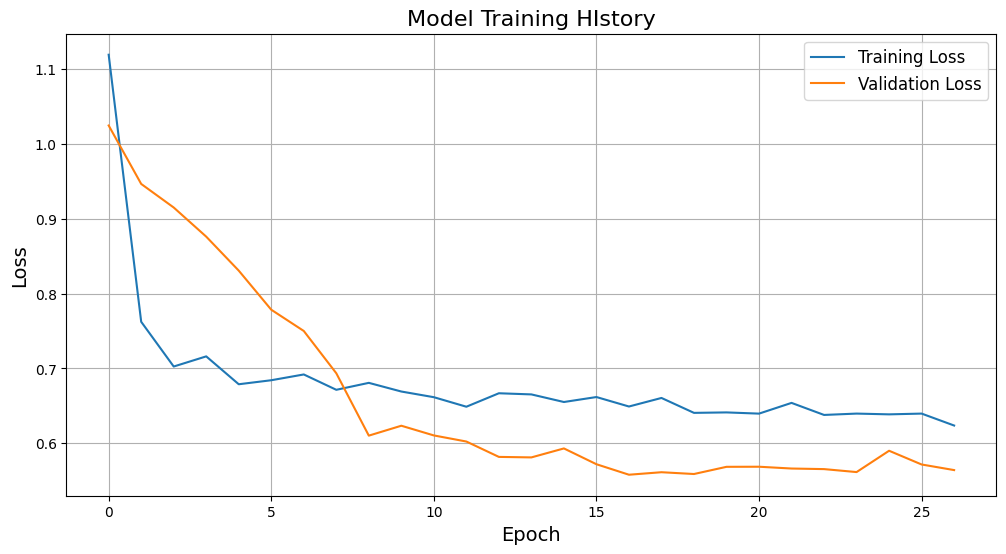

In [26]:
# 訓練の履歴をプロット
def plot_training_history(history):
    """訓練履歴と損失のプロット"""
    plt.figure(figsize=(12,6)) # グラフのサイズ

    plt.plot(history.history['loss'],label='Training Loss') # 訓練データの損失
    plt.plot(history.history['val_loss'],label='Validation Loss') # 検証データの損失

    plt.title('Model Training HIstory',fontsize=16) # タイトル
    plt.xlabel('Epoch',fontsize=14) # X軸ラベル
    plt.ylabel('Loss',fontsize=14) # Y軸ラベル
    plt.legend(fontsize=12) # 凡例
    plt.grid(True) # グリッド線
    plt.show() # グラフの表示

plot_training_history(history)
# (補足)検証損失とはみたこと無いデータに対しての誤差を表す

/opt/homebrew/var/pyenv/versions/3.12.6/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [04:36:03] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "objextive" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


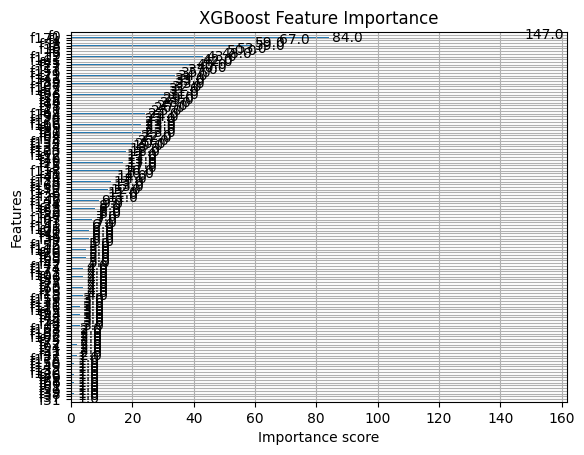

In [27]:
# Train XGBoost model
xgb_model.fit(xgb_X_train, y_train_xgb) # XGBoostモデルの学習

# Feature importance
xgb.plot_importance(xgb_model) # 特徴量の重要度をプロット
plt.title('XGBoost Feature Importance') # タイトル
plt.show() # グラフの表示

# ハイブリッドモデル &評価

In [33]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 以前定義したXGBoost回帰予測を-1,0,1のクラスに丸める関数
def convert_regression_to_class(y_pred):
    y_class = np.where(y_pred < -0.5, -1,
               np.where(y_pred < 0.5, 0, 1))
    return y_class.astype(int)

# XGBoostのクラスをLSTMの0,1,2ラベル空間に変換
def convert_xgb_label_to_lstm_label(y_pred):
    y_class = convert_regression_to_class(y_pred)  # -1,0,1
    y_shifted = y_class + 1  # -1->0, 0->1, 1->2
    return y_shifted.astype(int)

# XGBoost予測をLSTMラベル形式の確率ベクトルに変換
def xgb_to_prob_lstm_labels(xgb_pred):
    y_lstm_labels = convert_xgb_label_to_lstm_label(xgb_pred)
    n_samples = len(y_lstm_labels)
    probs = np.zeros((n_samples, 3))
    for i, label in enumerate(y_lstm_labels):
        probs[i, label] = 1.0
    return probs

# --- ここからハイブリッドモデルの評価処理 ---

# LSTMモデルの予測（0,1,2の確率ベクトル）
lstm_pred_prob = lstm_model.predict(X_test_lstm)  # shape (n_samples, 3)

# XGBoostモデルの予測（連続値）
xgb_pred_raw = xgb_model.predict(xgb_X_test)

# XGBoost予測を確率ベクトルに変換（LSTMのラベル空間に合わせる）
xgb_pred_prob = xgb_to_prob_lstm_labels(xgb_pred_raw)

# アンサンブル（重み付け平均）
alpha = 0.8  # LSTM重視
ensemble_prob = alpha * lstm_pred_prob + (1 - alpha) * xgb_pred_prob

# 最終予測クラス（0,1,2）
final_pred = ensemble_prob.argmax(axis=1)

# 正解ラベル（-1,0,1 → 0,1,2に変換）
y_true = (y_test_xgb + 1).astype(int)

# 評価指標計算
print("ハイブリッドモデル評価")
print(f"Accuracy:  {accuracy_score(y_true, final_pred):.4f}")
print(f"Precision: {precision_score(y_true, final_pred, average='macro', zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_true, final_pred, average='macro', zero_division=0):.4f}")
print(f"F1 Score:  {f1_score(y_true, final_pred, average='macro', zero_division=0):.4f}")


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
ハイブリッドモデル評価
Accuracy:  0.8074
Precision: 0.2691
Recall:    0.3333
F1 Score:  0.2978


In [29]:
print(y_test_lstm[:5])
print(y_test_lstm.shape)

print(lstm_pred[:5])
print(lstm_pred.shape)



[[1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]]
(270, 3)
[[0.30352658 0.28677544 0.40969804]
 [0.30484477 0.2836393  0.4115159 ]
 [0.30542064 0.2834433  0.41113615]
 [0.30649248 0.28279963 0.41070792]
 [0.30724928 0.28209603 0.4106546 ]]
(270, 3)


In [30]:
from collections import Counter
print(Counter(y))  # 前処理前の y を確認


Counter({np.int64(0): 1082, np.int64(-1): 139, np.int64(1): 129})


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
予測ラベルの分布: [  0 270]
正解ラベルの分布: [ 26 218  26]


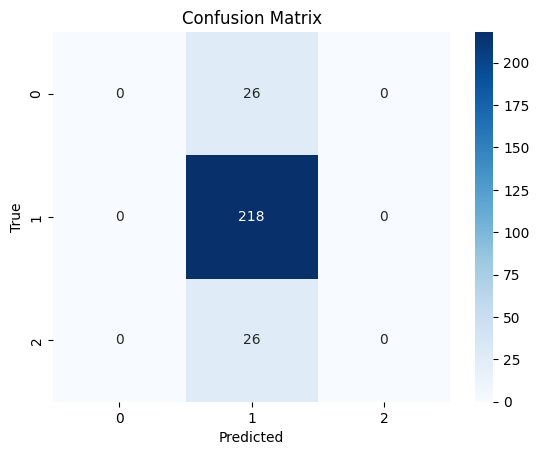

In [35]:
y_pred = lstm_model.predict(X_test_lstm)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test_lstm, axis=1)

# ラベル分布
import numpy as np
print("予測ラベルの分布:", np.bincount(final_pred))
print("正解ラベルの分布:", np.bincount(y_true_labels))

# 混同行列
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true_labels, final_pred, labels=[0,1,2])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1,2], yticklabels=[0,1,2])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


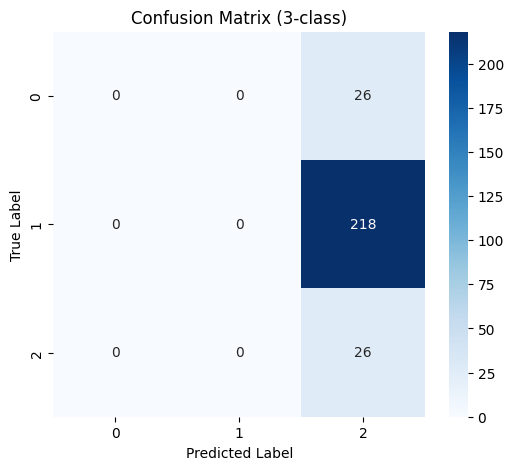

[[  0   0  26]
 [  0   0 218]
 [  0   0  26]]


In [32]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ラベル変換
true_labels = y_test_lstm.argmax(axis=1) if len(y_test_lstm.shape) > 1 else y_test_lstm
pred_labels = lstm_pred.argmax(axis=1)

# クラス数を明示的に指定（0, 1, 2）
labels = [0, 1, 2]

# 混同行列の計算
cm = confusion_matrix(true_labels, pred_labels, labels=labels)

# ヒートマップ表示
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (3-class)')
plt.show()

print(cm)